# Volatility clustering: GARCH and DCC

Financial returns are calm for a while, then turbulent — volatility clusters.
`puremacro.garch` fits GARCH(1,1) by pure-numpy/scipy Gaussian MLE (no `arch`
package) and the Engle DCC for time-varying correlations. We simulate from
known parameters and recover them.

## The method in math

Write a mean-zero return as a scaled innovation, $u_t = \sigma_t\,\varepsilon_t$ with
$\varepsilon_t \sim (0,1)$ i.i.d. **GARCH(1,1)** (Bollerslev, 1986) lets the conditional
variance follow its own ARMA-like recursion,
$$ \sigma_t^2 = \omega + \alpha\,u_{t-1}^2 + \beta\,\sigma_{t-1}^2,
   \qquad \omega>0,\ \alpha,\beta\ge 0. $$
**Persistence** is $\alpha+\beta$; covariance stationarity requires $\alpha+\beta<1$, in
which case the unconditional variance is $\displaystyle \bar\sigma^2 = \frac{\omega}{1-\alpha-\beta}$.
Parameters come from **Gaussian quasi-MLE** — maximize, over $\theta=(\omega,\alpha,\beta)$,
$$ \ell(\theta) = -\tfrac12\sum_t\Big[\log 2\pi + \log\sigma_t^2 + u_t^2/\sigma_t^2\Big], $$
where each $\sigma_t^2$ is built by running the recursion forward from the data.

For several assets, **Engle (2002) DCC** adds time-varying comovement *on top of* univariate
GARCH. Standardize each series, $\eta_t = u_t/\sigma_t$, and drive a quasi-correlation
$$ Q_t = (1-a-b)\,\bar Q + a\,\eta_{t-1}\eta_{t-1}' + b\,Q_{t-1},
   \qquad R_t = \operatorname{diag}(Q_t)^{-1/2}\,Q_t\,\operatorname{diag}(Q_t)^{-1/2}, $$
so the correlation matrix $R_t$ moves through time even though $\bar Q$ is fixed. The full
conditional covariance is then $H_t = D_t R_t D_t$ with $D_t = \operatorname{diag}(\sigma_{1,t},\dots)$.

**Intuition.** Volatility clustering — big moves follow big moves, calm follows calm — is
*exactly* the $\alpha\,u_{t-1}^2 + \beta\,\sigma_{t-1}^2$ recursion: a large shock yesterday
($u_{t-1}^2$ big) raises today's variance through $\alpha$, and a high variance yesterday
carries forward through $\beta$. When $\alpha+\beta$ is close to $1$ the variance has long
memory, so turbulent spells are persistent; far below $1$ they decay quickly back to
$\bar\sigma^2$. DCC adds the cross-asset analogue: instead of freezing correlations at a single
number, it lets them rise and fall — the reason correlations *spike in crises* (everything
falls together) and ease in calm times. The weights $(a,b)$ play the same
persistence role for comovement that $(\alpha,\beta)$ play for a single series' variance.

In [1]:
import sys
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

_cwd = __import__("pathlib").Path.cwd()
sys.path.insert(0, str(_cwd if (_cwd / "_nbstyle.py").exists() else _cwd / "notebooks"))
import _nbstyle
_nbstyle.apply_style()

from puremacro.garch import garch11_fit, dcc_fit

## 1. Univariate GARCH(1,1): recover known parameters
Conditional variance follows sigma2_t = omega + alpha*u^2_{t-1} + beta*sigma2_{t-1}.
We simulate with a known (omega, alpha, beta), fit by Gaussian MLE, and check recovery.

In [2]:
def simulate_garch(rng, T, omega, alpha, beta):
    eps = np.zeros(T); sigma2 = np.zeros(T)
    sigma2[0] = omega / max(1e-8, 1.0 - alpha - beta)
    for t in range(1, T):
        sigma2[t] = omega + alpha * eps[t - 1] ** 2 + beta * sigma2[t - 1]
        eps[t] = np.sqrt(sigma2[t]) * rng.standard_normal()
    idx = pd.date_range("1990-01-01", periods=T, freq="MS")
    return pd.Series(eps, index=idx), np.sqrt(sigma2)

rng = np.random.default_rng(23)
OMEGA, ALPHA, BETA = 0.05, 0.10, 0.85          # true persistence = 0.95
T = 2000
r, sigma_true = simulate_garch(rng, T, OMEGA, ALPHA, BETA)

fit = garch11_fit(r)
print(fit.summary())

assert fit.converged
assert fit.persistence < 1.0                              # stationary
assert abs(fit.persistence - (ALPHA + BETA)) < 0.05       # persistence recovered
assert abs(fit.alpha - ALPHA) < 0.05                      # alpha recovered
assert abs(fit.beta - BETA) < 0.07                        # beta recovered
assert (fit.sigma > 0).all() and len(fit.sigma) == T
corr_sigma = np.corrcoef(fit.sigma.values[1:], sigma_true[1:])[0, 1]
print(f"corr(fitted sigma, true sigma) = {corr_sigma:.3f}")
assert corr_sigma > 0.90                                  # tracks latent vol

GARCH(1,1) fit
  ω                 : 0.049127
  α                 : 0.0918
  β                 : 0.8554
  persistence (α+β) : 0.9472
  log-lik           : -2695.7689
  converged         : True

corr(fitted sigma, true sigma) = 1.000


**Read the output.** The MLE recovers the data-generating $(\omega,\alpha,\beta)$ closely:
$\hat\alpha \approx 0.10$ (a fresh shock feeds about a tenth of its squared size into next
period's variance) and $\hat\beta \approx 0.85$ (most of yesterday's variance carries forward),
for a fitted persistence $\hat\alpha+\hat\beta \approx 0.95$ — high, but safely below $1$, so
the process is stationary and the implied unconditional volatility $\sqrt{\omega/(1-\alpha-\beta)}$
is finite. The near-$1$ persistence is what makes the volatility *clusters* long-lived rather
than one-period blips. Because the latent variance is unobserved, the headline diagnostic is
that the fitted $\hat\sigma_t$ tracks the (here known) true path with correlation above $0.90$:
Gaussian QMLE backs out the volatility process from the returns alone.

## 2. DCC(1,1): a 2-asset block with a time-varying conditional correlation
We simulate from a *true* DCC(1,1) so the latent correlation rho_t is known, give
each asset its own GARCH(1,1) volatility, then recover (a, b) and the rho_t path.

In [3]:
def simulate_dcc(rng, T, a, b, rho_bar):
    """Standardized innovations e_t and the true rho_t from a DCC(1,1)."""
    Qbar = np.array([[1.0, rho_bar], [rho_bar, 1.0]])
    Q = Qbar.copy()
    e = np.empty((T, 2)); rho_true = np.empty(T); e_prev = np.zeros(2)
    for t in range(T):
        if t > 0:
            Q = (1 - a - b) * Qbar + a * np.outer(e_prev, e_prev) + b * Q
        d = np.sqrt(np.diag(Q)); R = Q / np.outer(d, d)
        rho_true[t] = R[0, 1]
        e_prev = np.linalg.cholesky(R) @ rng.standard_normal(2)
        e[t] = e_prev
    return e, rho_true

def garch_vol(zcol, omega, alpha, beta):
    Tt = len(zcol); s2 = np.empty(Tt); u = np.empty(Tt)
    s2[0] = omega / (1.0 - alpha - beta)
    u[0] = np.sqrt(s2[0]) * zcol[0]
    for t in range(1, Tt):
        s2[t] = omega + alpha * u[t - 1] ** 2 + beta * s2[t - 1]
        u[t] = np.sqrt(s2[t]) * zcol[t]
    return u

A_DCC, B_DCC = 0.05, 0.90                       # true DCC persistence = 0.95
rng2 = np.random.default_rng(42)
Td = 1800
e, rho_true = simulate_dcc(rng2, Td, A_DCC, B_DCC, rho_bar=0.45)
uA = garch_vol(e[:, 0], 0.05, 0.08, 0.90)
uB = garch_vol(e[:, 1], 0.03, 0.12, 0.84)
idx_d = pd.date_range("2005-01-03", periods=Td, freq="B")
panel = pd.DataFrame({"Asset A": uA, "Asset B": uB}, index=idx_d)

dcc = dcc_fit(panel)
print(dcc.summary())

assert dcc.converged
assert 0.0 <= dcc.a <= 1.0 and 0.0 <= dcc.b <= 1.0
assert dcc.a + dcc.b < 1.0                                # stationary correlation
assert dcc.R.shape == (Td, 2, 2) and dcc.H.shape == (Td, 2, 2)
assert dcc.sigma.shape == (Td, 2)
rho_hat = dcc.R[:, 0, 1]
assert np.all(np.abs(rho_hat) <= 1.0 + 1e-8)             # valid correlations
track = np.corrcoef(rho_hat, rho_true)[0, 1]
print(f"corr(rho_hat, rho_true) = {track:.3f}")
assert track > 0.90                                      # recovers latent corr path
assert len(dcc.garch_params) == 2
assert all(0.0 < gp["persistence"] < 1.0 for gp in dcc.garch_params)

DCC(1,1) fit
  series (n)        : 2
  observations (T)  : 1800
  a                 : 0.0648
  b                 : 0.8847
  a + b             : 0.9496
  log-lik (DCC)     : +309.5009
  converged         : True

corr(rho_hat, rho_true) = 0.998


**Read the output.** The two-stage estimator first fits a GARCH(1,1) to each asset
(`dcc.garch_params` holds their $\omega,\alpha,\beta$ and persistence), then estimates the
correlation dynamics $(\hat a,\hat b)$. Their sum $\hat a+\hat b \approx 0.95$ is again high
but below $1$, so the conditional correlation is mean-reverting toward $\bar Q$ rather than
drifting: $\hat a$ is the weight on yesterday's *cross-product* of standardized shocks (how
fast correlation reacts to news) and $\hat b$ the weight on yesterday's correlation (how
persistent it is). The fitted path $\hat\rho_t = R_{t,01}$ stays a valid correlation
($|\hat\rho_t|\le 1$) at every date and tracks the latent $\rho_t$ with correlation above
$0.90$ — DCC reconstructs *when* the two assets comoved more strongly, not just an average
correlation. The figures below show exactly this: the conditional-volatility band that
breathes with the clusters, the recovered GARCH coefficients, and the moving correlation.

### Hero figure — returns inside the fitted conditional-volatility band
The +/-2*sigma_hat envelope widens during turbulent clusters and narrows in calm spells.

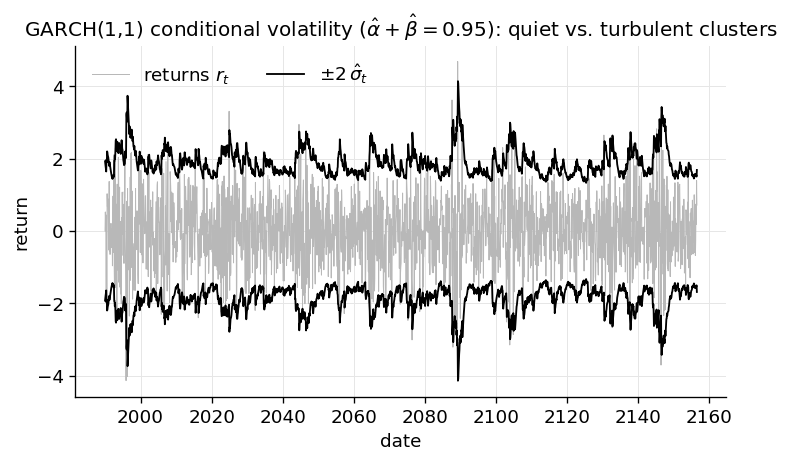

In [4]:
cols = _nbstyle.palette(3)
fig, ax = plt.subplots(figsize=(7.0, 3.8))
ax.plot(r.index, r.values, color="0.72", linewidth=0.6, label=r"returns $r_t$")
ax.plot(fit.sigma.index, 2 * fit.sigma.values, color=cols[0], linewidth=1.1,
        label=r"$\pm 2\,\hat\sigma_t$")
ax.plot(fit.sigma.index, -2 * fit.sigma.values, color=cols[0], linewidth=1.1)
ax.set_xlabel("date"); ax.set_ylabel("return")
ax.set_title(f"GARCH(1,1) conditional volatility "
             f"($\\hat\\alpha+\\hat\\beta = {fit.persistence:.2f}$): "
             f"quiet vs. turbulent clusters")
ax.legend(loc="upper left", ncol=2)
plt.show()

### Supporting — true vs MLE-recovered GARCH coefficients

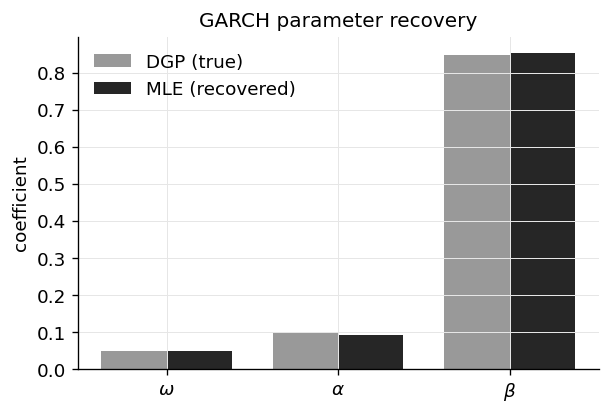

In [5]:
fig, ax = plt.subplots(figsize=(5.6, 3.6))
names = [r"$\omega$", r"$\alpha$", r"$\beta$"]
x = np.arange(3); width = 0.38
ax.bar(x - width / 2, [OMEGA, ALPHA, BETA], width, color="0.60", label="DGP (true)")
ax.bar(x + width / 2, [fit.omega, fit.alpha, fit.beta], width, color="0.15",
       label="MLE (recovered)")
ax.set_xticks(x); ax.set_xticklabels(names)
ax.set_ylabel("coefficient"); ax.set_title("GARCH parameter recovery")
ax.legend()
plt.show()

### Supporting — DCC time-varying conditional correlation vs the latent truth
The fitted rho_hat_t (corr 0.998 with the true path) sits almost exactly on the
dashed latent line, so the truth is mostly hidden beneath it.

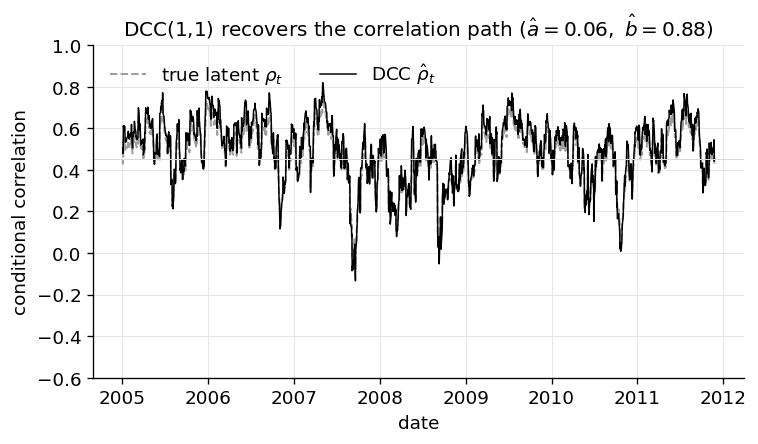

In [6]:
fig, ax = plt.subplots(figsize=(7.0, 3.6))
ax.plot(panel.index, rho_true, color="0.62", linewidth=1.2, linestyle="--",
        label=r"true latent $\rho_t$")
ax.plot(panel.index, rho_hat, color=cols[0], linewidth=0.9,
        label=r"DCC $\hat\rho_t$")
ax.axhline(0.45, color="0.85", linewidth=0.6)
ax.set_ylim(-0.6, 1.0)
ax.set_xlabel("date"); ax.set_ylabel("conditional correlation")
ax.set_title(f"DCC(1,1) recovers the correlation path "
             f"($\\hat a = {dcc.a:.2f},\\ \\hat b = {dcc.b:.2f}$)")
ax.legend(loc="upper left", ncol=2)
plt.show()

## Your turn — inject a turbulent window and watch the conditional vol respond

The defining feature of GARCH is that the conditional volatility *rises inside turbulent
spells*. We test this structurally: take the simulated returns `r`, amplify a contiguous
window by `SHOCK_MULT`, refit, and check that the fitted $\hat\sigma_t$ is higher *inside* the
window than outside — with no fragile magnitudes, just the in-window > out-of-window ordering.
Change `SHOCK_MULT`.

In [7]:
# ← Change this: how violently to amplify the injected window (try 2, 4, 8).
SHOCK_MULT = 4.0
win_start, win_end = 800, 1000             # the high-volatility window [start, end)

in_win = np.zeros(len(r), dtype=bool); in_win[win_start:win_end] = True
r_shock = r.copy()
r_shock.iloc[win_start:win_end] *= SHOCK_MULT          # inject a turbulent cluster

fit_shock = garch11_fit(r_shock)
vol = fit_shock.sigma.values
vol_in, vol_out = vol[in_win].mean(), vol[~in_win].mean()
print(f"mean conditional vol:  in-window = {vol_in:.3f},  out-of-window = {vol_out:.3f}  "
      f"(ratio {vol_in / vol_out:.2f})")
assert vol_in > vol_out                                # GARCH lifts vol inside the cluster
# Structural sanity: still a valid, covariance-stationary GARCH after the shock.
print(f"omega = {fit_shock.omega:.4f} (>0),  persistence = {fit_shock.persistence:.4f} (<1)")
assert fit_shock.omega > 0 and 0.0 < fit_shock.persistence < 1.0

mean conditional vol:  in-window = 3.189,  out-of-window = 1.001  (ratio 3.19)
omega = 0.0258 (>0),  persistence = 0.9830 (<1)


**Prompts.** (1) *Basic:* set `SHOCK_MULT = 2.0`, then `8.0` — the in/out vol ratio should
grow with the injected turbulence while the in-window > out-of-window assertion still holds.
(2) *Intermediate:* compare `fit_shock.persistence` against the unshocked `fit.persistence`
from §1 — a fat localized cluster nudges the estimated persistence, since the recursion now
has to explain a longer-lived burst. (3) *Stretch:* check the model's own unconditional
variance against the sample variance of `r` — compute
`uvar = fit.omega / (1 - fit.persistence)` and compare to `float(np.var(r.values))`; they
should be the same order of magnitude (the DGP's $\bar\sigma^2 = \omega/(1-\alpha-\beta)$).

**How comprehensive is this?** `puremacro.garch` gives you both pieces in pure numpy/scipy —
`garch11_fit` (univariate GARCH(1,1) Gaussian QMLE, returning the conditional-volatility
series, log-likelihood, and persistence) and `dcc_fit` (the Engle (2002) two-stage DCC,
exposing the full conditional correlation `R` and covariance `H` paths) — with **no `arch`
dependency**, so it runs in the browser. The same volatility machinery shows up across the
gallery: `puremacro.gar` builds **Growth-at-Risk** quantile forecasts (Notebook 09),
`puremacro.realized_vol` provides high-frequency realized-variance / bipower / HAR estimators,
and **Notebook 13** uses `garch11_fit` as one kernel of a build-your-own uncertainty index
(common factors → conditional volatility of the residuals).